# Agrupamento de Dados com Algoritmo Genético Híbrido (GA + K-Means)

**Aluno**: Filipe Gomes Arante de Souza

Este notebook documenta um experimento de **agrupamento não-supervisionado** utilizando um **Algoritmo Genético (AG)** como método de otimização global, acelerado pelo **K-Means** como operador de busca local.

O objetivo é encontrar bons agrupamentos em conjuntos de dados clássicos, evoluindo centroides por meio de um AG e refinando-os periodicamente com o K-Means para escapar de mínimos locais de forma mais eficiente.

Os experimentos são realizados sobre dois conjuntos de dados bem conhecidos: **Iris** e **Wine**.

## 1. Datasets Utilizados

### 1.1 Iris

O *Iris* é um dos conjuntos de dados mais utilizados em aprendizado de máquina, introduzido por Ronald Fisher em 1936.

| Propriedade | Valor |
|---|---|
| Amostras | 150 |
| Atributos | 4 (comprimento e largura de sépala e pétala, em cm) |
| Classes | 3 (*Iris setosa*, *Iris versicolor*, *Iris virginica*) |
| Balanceamento | 50 amostras por classe |

---

### 1.2 Wine

O *Wine* contém resultados de análise química de vinhos produzidos na mesma região da Itália, provenientes de três cultivares distintas.

| Propriedade | Valor |
|---|---|
| Amostras | 178 |
| Atributos | 13 (álcool, ácido málico, cinzas, alcalinidade, magnésio, fenóis, flavonoides, etc.) |
| Classes | 3 (0, 1 e 2) |
| Balanceamento | Levemente desbalanceado (59, 71 e 48 amostras) |

In [1]:
from typing import List, Optional, Dict, Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_wine
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.utils import Bunch
from sko.GA import RCGA

## 2. Implementação

### 2.1 Classe `Dataset`

Wrapper simples sobre `sklearn.utils.Bunch` que agrupa os dados numéricos, o nome do dataset e os nomes das classes.  
O atributo `number_of_groups` é derivado automaticamente do tamanho de `class_names`, e é usado para definir o número de clusters $k$.

In [2]:
class Dataset:
    def __init__(self, data: np.ndarray, name: str, class_names: List[str]):
        self.data = data
        self.name = name
        self.class_names = class_names
        self.number_of_groups = len(class_names)

    @classmethod
    def from_bunch(cls, bunch: Bunch, name: str) -> 'Dataset':
        return cls(bunch.data, name, bunch.target_names)

### 2.2 Algoritmo Genético

O Algoritmo Genético foi implementado com as seguintes operações:

1. Seleção por torneio;
2. Crossover aritmético;
3. Mutação gaussiana.

#### Representação do Indivíduo (Cromossomo)

Cada indivíduo na população codifica $k$ centroides concatenados em um vetor de reais:

$$\text{indivíduo} = [c_1^{(1)}, c_1^{(2)}, \ldots, c_1^{(d)},\; c_2^{(1)}, \ldots, c_k^{(d)}]$$

onde $k$ é o número de grupos e $d$ é o número de atributos. Assim, a dimensão do espaço de busca é $n\_dim = k \times d$.

O tamanho da população e o número máximo de iterações são derivados automaticamente:

$$\text{size\_pop} = 3 \times n\_dim \qquad \text{max\_iter} = 10 \times n\_dim$$

Os limites inferior e superior de cada gene correspondem ao mínimo e máximo de cada atributo no dataset.

---

#### Função de Aptidão (*Fitness*)

A função objetivo a ser minimizada é a soma das distâncias euclidianas de cada ponto ao seu centroide mais próximo (distância intracluster):

$$f(\mathbf{x}) = \sum_{i=1}^{n} \min_{k} \| x_i - c_k \|_2$$

---

#### K-Means como Acelerador de Busca Local

Nas primeiras $\lfloor \text{max\_iter} / 10 \rfloor$ gerações, um indivíduo tem seus centroides refinados pelo K-Means:

- Na primeira geração, o melhor indivíduo da população é refinado.
- Nas gerações seguintes (até o limite), um indivíduo aleatório é refinado.

O K-Means é inicializado com os centroides do indivíduo selecionado (`init=centroids, n_init=1`) e executado por convergência. Se o fitness do resultado for melhor, o indivíduo é substituído no cromossomo.

Esse mecanismo híbrido combina a exploração global do AG com a intensificação local do K-Means, acelerando a convergência especialmente no início da evolução.

In [3]:
class GeneticAlgorithm(RCGA):
    MUTATION_PROBABILITY = 0.01
    MUTATION_MEAN = 0
    MUTATION_STD = 0.1

    def __init__(self, dataset: Dataset, number_of_groups: int):
        self.dataset = dataset
        self.number_of_groups = number_of_groups
        n_features = dataset.data.shape[1]

        n_dimensions = number_of_groups * n_features
        population_size = 3 * n_dimensions if n_dimensions % 2 == 0 else 3 * n_dimensions + 1

        super().__init__(
            func=self.fitness,
            n_dim=n_dimensions,
            size_pop=population_size,
            max_iter=10 * n_dimensions,
            prob_mut=self.MUTATION_PROBABILITY,
            lb=dataset.data.min(axis=0).tolist() * number_of_groups,
            ub=dataset.data.max(axis=0).tolist() * number_of_groups,
        )

        self.register('mutation', type(self).gaussian_mutation)
        self.register('crossover', type(self).arithmetic_crossover)

    def fitness(self, individual: np.ndarray) -> float:
        centroids = individual.reshape(self.number_of_groups, self.dataset.data.shape[1])
        distances: np.ndarray = np.linalg.norm(
            self.dataset.data[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2
        )
        min_distances: np.ndarray = distances.min(axis=1)
        return min_distances.sum()

    def apply_kmeans(self, idx: int) -> None:
        centroids = self.X[idx].reshape(self.number_of_groups, self.dataset.data.shape[1])

        kmeans = KMeans(
            n_clusters=self.number_of_groups,
            init=centroids,
            n_init=1,
        )
        kmeans.fit(self.dataset.data)

        refined = kmeans.cluster_centers_.flatten()
        new_fitness = self.func(np.array([refined]))[0]

        if new_fitness < self.Y[idx]:
            self.Chrom[idx] = (refined - self.lb) / (self.ub - self.lb)
            self.X[idx] = refined
            self.Y[idx] = new_fitness

    def run(self, max_iter=None):
        self.max_iter = max_iter or self.max_iter
        kmeans_limit = self.max_iter // 10
        best = []

        for i in range(self.max_iter):
            self.X = self.chrom2x(self.Chrom)
            self.Y = self.x2y()

            if i < kmeans_limit:
                idx = int(self.Y.argmin()) if i == 0 else np.random.randint(0, self.size_pop)
                self.apply_kmeans(idx)

            self.ranking()
            self.selection()
            self.crossover()
            self.mutation()

            generation_best_index = self.FitV.argmax()
            self.generation_best_X.append(self.X[generation_best_index, :])
            self.generation_best_Y.append(self.Y[generation_best_index])
            self.all_history_Y.append(self.Y)
            self.all_history_FitV.append(self.FitV)

            if self.early_stop:
                best.append(min(self.generation_best_Y))
                if len(best) >= self.early_stop:
                    if best.count(min(best)) == len(best):
                        break
                    else:
                        best.pop(0)

        global_best_index = np.array(self.generation_best_Y).argmin()
        self.best_x = self.generation_best_X[global_best_index]
        self.best_y = self.func(np.array([self.best_x]))

        return self.best_x, self.best_y

    def get_clusters(self) -> np.ndarray:
        centroids = self.best_x.reshape(self.number_of_groups, self.dataset.data.shape[1])
        distances = np.linalg.norm(
            self.dataset.data[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2
        )
        return distances.argmin(axis=1)

    def gaussian_mutation(self):
        for i in range(self.size_pop):
            for j in range(self.n_dim):
                if np.random.random() <= self.prob_mut:
                    self.Chrom[i][j] += np.random.normal(self.MUTATION_MEAN, self.MUTATION_STD)
                    self.Chrom[i][j] = np.clip(self.Chrom[i][j], 0, 1)
        return self.Chrom

    def arithmetic_crossover(self):
        for i in range(0, self.size_pop, 2):
            if np.random.random() > self.prob_cros:
                continue
            alpha = np.random.random()
            child1 = alpha * self.Chrom[i] + (1 - alpha) * self.Chrom[i + 1]
            child2 = alpha * self.Chrom[i + 1] + (1 - alpha) * self.Chrom[i]
            self.Chrom[i] = np.clip(child1, 0, 1)
            self.Chrom[i + 1] = np.clip(child2, 0, 1)
        return self.Chrom

    def plot(self) -> None:
        labels = self.get_clusters()
        dataset_3d, centroids_3d = self.get_3d_points_for_plot()

        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')

        for i in range(self.number_of_groups):
            mask = labels == i
            ax.scatter(dataset_3d[mask, 0], dataset_3d[mask, 1], dataset_3d[mask, 2], s=20, label=self.dataset.class_names[i].capitalize())

        ax.scatter(centroids_3d[:, 0], centroids_3d[:, 1], centroids_3d[:, 2], s=20, c='black', label='Centroids')
        ax.legend()
        ax.set_title(f'Dataset {self.dataset.name.capitalize()} - Clusters GA+K-Means (PCA 3D)')

        plt.tight_layout()
        plt.show()

    def get_3d_points_for_plot(self):
        n_features = self.dataset.data.shape[1]
        centroids = self.best_x.reshape(self.number_of_groups, n_features)

        if n_features > 3:
            pca = PCA(n_components=3)
            pca.fit(self.dataset.data)
            dataset_3d = pca.transform(self.dataset.data)
            centroids_3d = pca.transform(centroids)
        elif n_features == 3:
            dataset_3d = self.dataset.data
            centroids_3d = centroids
        elif n_features == 2:
            dataset_3d = np.hstack([self.dataset.data, np.zeros((len(self.dataset.data), 1))])
            centroids_3d = np.hstack([centroids, np.zeros((self.number_of_groups, 1))])
        elif n_features == 1:
            dataset_3d = np.hstack([self.dataset.data, np.zeros((len(self.dataset.data), 2))])
            centroids_3d = np.hstack([centroids, np.zeros((self.number_of_groups, 2))])
        else:
            raise ValueError("Dataset must have at least 1 feature")

        return dataset_3d, centroids_3d

### 2.3 Classe `Runner`

Orquestra múltiplas execuções independentes do AG sobre um mesmo dataset.

Ao final de todas as execuções, `Runner` identifica o índice da melhor solução (`_best_idx`) para uso na visualização e coleta as seguintes métricas:

1. **Fitness Médio:** Média do melhor fitness encontrado em cada execução;
2. **Desvio Padrão:** Variabilidade do fitness entre as execuções;
3. **Melhor Fitness:** Menor valor de fitness obtido em todas as execuções.

In [4]:
class Runner:
    def __init__(self, dataset: Dataset, run_times: int):
        self.dataset = dataset
        self.run_times = run_times

        self._best_fitnesses: List[float] = []
        self._best_solutions: List[np.ndarray] = []
        self._genetic_algorithms: List[GeneticAlgorithm] = []
        self._best_idx: Optional[int] = None

    def run(self) -> None:
        for i in range(self.run_times):
            genetic_algorithm = GeneticAlgorithm(self.dataset, self.dataset.number_of_groups)
            best_solution, best_fitness = genetic_algorithm.run()

            self._best_fitnesses.append(best_fitness[0])
            self._best_solutions.append(best_solution)
            self._genetic_algorithms.append(genetic_algorithm)

        self._best_idx = int(np.argmin(self._best_fitnesses))

    def plot(self) -> None:
        if self._best_idx is None:
            return

        self._genetic_algorithms[self._best_idx].plot()

    def get_dataframe_row(self) -> Dict[str, Union[str, float]]:
        if self._best_idx is None:
            return {}

        return {
            'Dataset': self.dataset.name,
            'Fitness Médio': np.mean(self._best_fitnesses),
            'Desvio Padrão': np.std(self._best_fitnesses),
            'Melhor Fitness': self._best_fitnesses[self._best_idx],
        }

## 3. Execução dos Experimentos

O AG é executado **10 vezes** para cada dataset. A cada rodada, uma nova instância do AG é criada com população inicializada aleatoriamente.

Ao final, as métricas de cada rodada são agregadas pela classe `Runner`.

In [5]:
RUN_TIMES = 10

datasets = [
    Dataset.from_bunch(load_iris(), 'iris'),
    Dataset.from_bunch(load_wine(), 'wine'),
]

runners: List[Runner] = []
dataframe_rows: List[Dict[str, Union[str, float]]] = []

for dataset in datasets:
    print(f'\nRunning GA on dataset {dataset.name}')
    runner = Runner(dataset, RUN_TIMES)
    runner.run()
    runners.append(runner)
    dataframe_rows.append(runner.get_dataframe_row())


Running GA on dataset iris

Running GA on dataset wine


## 4. Tabela de Resultados

A tabela abaixo resume, para cada dataset, as métricas coletadas ao longo das 10 execuções do AG híbrido.

- **Fitness Médio**: média da função objetivo obtida nas 10 rodadas;
- **Desvio Padrão**: variabilidade entre as rodadas;
- **Melhor Fitness**: menor valor da função objetivo encontrado em todas as rodadas.

In [6]:
results_dataframe = pd.DataFrame(dataframe_rows)
results_dataframe

,Dataset,Fitness Médio,Desvio Padrão,Melhor Fitness
0,iris,96.610533,0.035556,96.559781
1,wine,16294.323664,0.219202,16293.844029


## 5. Visualização dos Clusters

Os gráficos abaixo exibem os clusters encontrados pela melhor rodada de cada dataset, projetados em 3 dimensões.

Como os datasets possuem mais de 3 atributos, foi aplicado **PCA** para reduzir a dimensionalidade para permitir a visualização dos dados.

Os centróides estão marcados de preto.

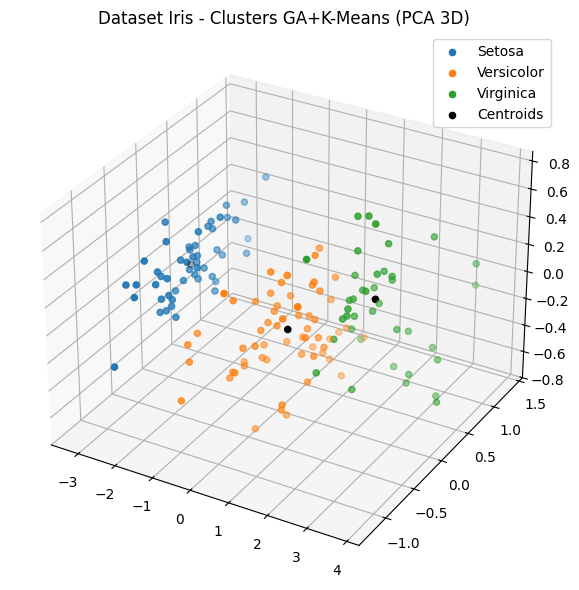

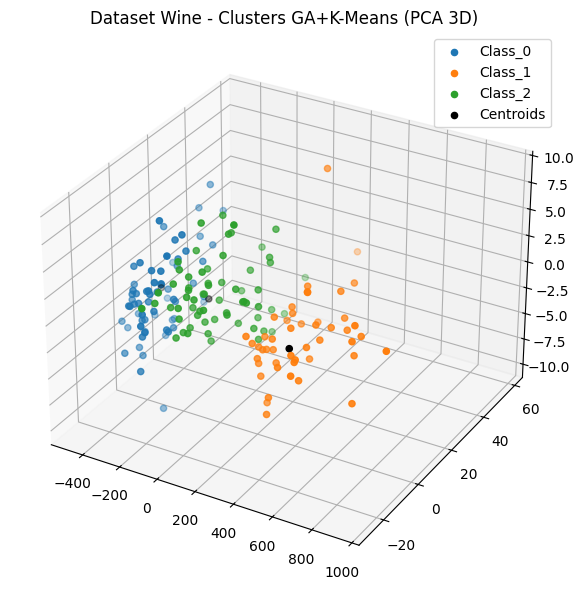

In [7]:
for runner in runners:
    runner.plot()